In [1]:
import numpy as np
np.set_printoptions(suppress=True, precision=2)
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = 'serif'
import kineticmodel as k

In [2]:
# simulation time and dt
tsteps = 8000
dt = 1 # step
time_axis = np.arange(tsteps) * dt

In [3]:
well_depths = [
    [30000, 10000],
    [3000, 1000],
    [300, 100]
]
connections = [100, 3, 10, 1, 3]

C, labels = k.build_metastable_counts(
    well_depths,
    connections
)

N, n_macro = C.shape[0], 3
print(C)
print(N, n_macro)

[[30000.   100.     0.     0.     0.     0.]
 [  100. 10000.     3.     0.     0.     0.]
 [    0.     3.  3000.    10.     0.     0.]
 [    0.     0.    10.  1000.     1.     0.]
 [    0.     0.     0.     1.   300.     3.]
 [    0.     0.     0.     0.     3.   100.]]
6 3


In [4]:
# 1. Symmetrize count matrix
C_sym = k.symmetrize(C)

# 2. Convert counts into a transition probability matrix
TPM = k.tpm_from_counts(C_sym)

# 3. Build macrostate assignment matrix
assnt = k.assignment_matrix(labels)
print(assnt)

# 4. Get equilibrium populations
pi = k.equilibrium_populations(C)
print(pi)

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
[0.67 0.23 0.07 0.02 0.01 0.  ]


In [8]:
PAD = k.hummer_szabo_projector(assnt, pi)
dynamics = k.coarse_grained_dynamics(TPM, assnt, PAD, tsteps, axis="Tnn")
np.save("kineticmodel.npy", dynamics, allow_pickle=True)

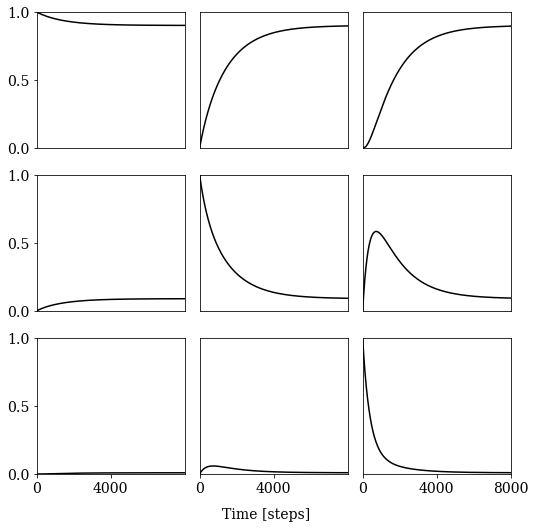

In [9]:
k.plot_coarse_grained_dynamics(time_axis, dynamics, n_macro, tsteps, save=True)